# Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
path = "../data/raw/spotify_tracks.csv"

df = pd.read_csv(path)

print(f"Log entries: {df.shape[0]}, Columns: {df.shape[1]}\n")

print(df.sample(3))

Log entries: 114000, Columns: 21

       Unnamed: 0                track_id                       artists  \
58016       58016  7LyODTwVRK0KN0615tcBPq                Marilyn Manson   
98627       98627  3ArDpTyZA5upNyiiOzm614  Colin Donnell;Solea Pfeiffer   
40365       40365  5nOzM5Onid922yer0Oy7bC                  Palavrantiga   

                                              album_name  \
58016                              Halloween Scary Party   
98627  Songs for a New World (New York City Center 20...   
40365                                 Esperar é Caminhar   

                    track_name  popularity  duration_ms  explicit  \
58016     The Beautiful People           0       222773      True   
98627  I'd Give It All for You          23       302813     False   
40365               Rookmaaker          42       266472     False   

       danceability  energy  ...  loudness  mode  speechiness  acousticness  \
58016         0.609   0.948  ...    -4.938     1       0.1130       

In [8]:
# Schema types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

## Descriptive Summary Statistics

In [11]:
# Numeric Values
print(df.describe())

          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.472000       2.000000     -1

In [12]:
# Count the number of tracks per genre 
print(df['track_genre'].value_counts())

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


In [13]:
print(df['explicit'].value_counts())

explicit
False    104253
True       9747
Name: count, dtype: int64


## Spotting Nulls, Duplicates, Anomalies

In [14]:
# Missing Values per column
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [18]:
print(df.duplicated().sum())

0


In [19]:
# Count how many times the same 'track_id' is repeated in the raw dataset
print(df['track_id'].duplicated().sum()) 

24259


## Visualizing Distributions and Outliers

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

### Plot 1: Popularity Distribution Histogram

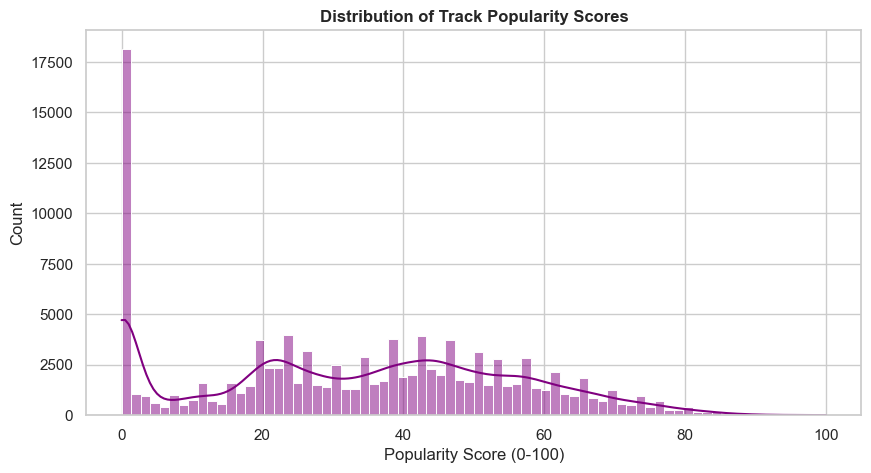

In [23]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='popularity', kde=True, color="purple")

plt.title("Distribution of Track Popularity Scores", fontsize=12, fontweight='bold')
plt.xlabel("Popularity Score (0-100)")
plt.ylabel("Count")
plt.show()

### Plot 2: Spotting Audio Feature Outliers (Boxplots)

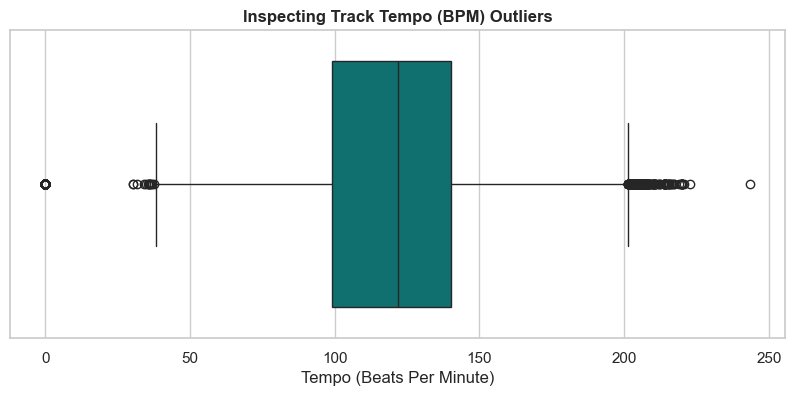

In [24]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x='tempo', color="teal")

plt.title("Inspecting Track Tempo (BPM) Outliers", fontweight='bold')
plt.xlabel("Tempo (Beats Per Minute)")
plt.show()

## Plot 3: Exploring Relationships (Tempo VS Loudness)

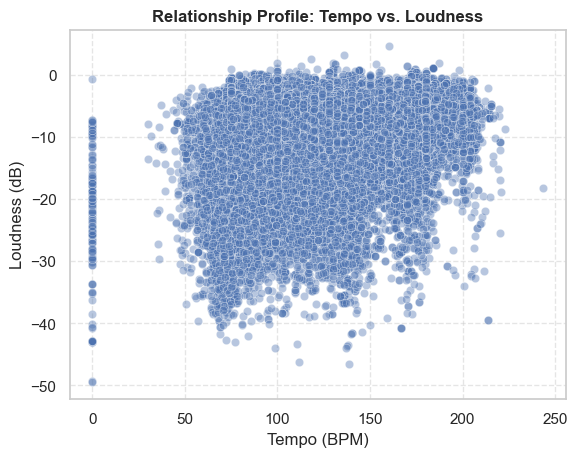

In [25]:
sns.scatterplot(data=df, x='tempo', y='loudness', alpha=0.4)

plt.title("Relationship Profile: Tempo vs. Loudness", fontsize=12, fontweight='bold')
plt.xlabel("Tempo (BPM)")
plt.ylabel("Loudness (dB)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()